In [1]:
!pip install yfinance prophet pandas matplotlib

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

In [5]:
import datetime

tickers = ["MDT", "JNJ", "SMMNY", "SYK", "GEHC"]

# Calculating time back 2 years
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=2*365)



In [6]:
# Ticker DataFrame Dictionary
data_dict = {}

for ticker in tickers:
    df = yf.download(ticker, start=start_date, end=end_date)
    data_dict[ticker] = df[['Close']]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [7]:
combined_closes = pd.DataFrame()

for ticker in tickers:
    combined_closes[ticker] = data_dict[ticker]['Close']

combined_closes.dropna(inplace=True)

In [8]:
daily_returns = combined_closes.pct_change()

In [9]:
index_daily_returns = daily_returns.mean(axis=1)

# Price series for the index (starting at 100)
index_value = (1 + index_daily_returns).cumprod() * 100

index_df = pd.DataFrame(index_value, columns=['IndexValue'])


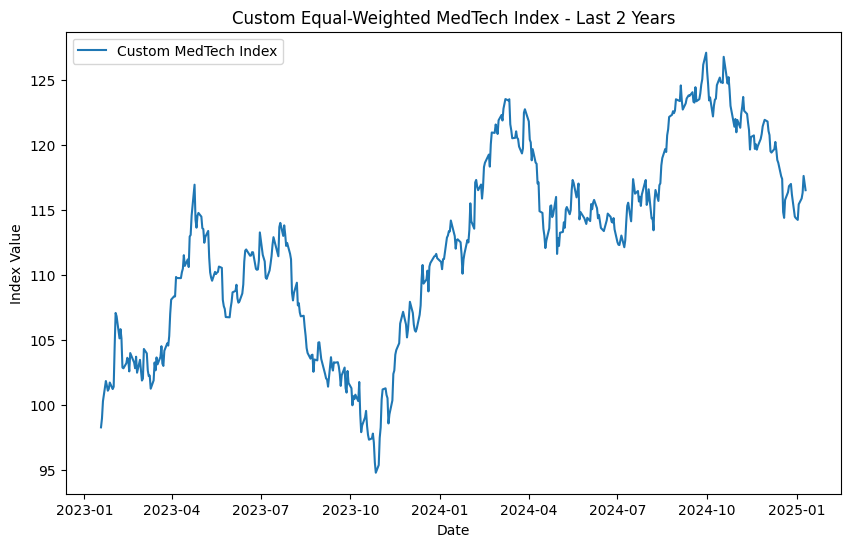

Index start value: nan
Index end value: 116.51
Total return: nan%
Annualized return (approx.): nan%
Annualized volatility (approx.): 13.94%


<ipython-input-10-00ec61d33bd5>:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_value = index_df['IndexValue'][-1]
<ipython-input-10-00ec61d33bd5>:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  start_value = index_df['IndexValue'][0]


In [10]:
# Backtesting
import matplotlib.dates as mdates

# --- Plotting the index ---
plt.figure(figsize=(10, 6))
plt.plot(index_df.index, index_df['IndexValue'], label='Custom MedTech Index')
plt.title("Custom Equal-Weighted MedTech Index - Last 2 Years")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.show()

# --- Performance stats ---
final_value = index_df['IndexValue'][-1]
start_value = index_df['IndexValue'][0]
total_return = (final_value - start_value) / start_value
annualized_return = (1 + total_return)**(365 / (index_df.shape[0])) - 1  # approximate
volatility = index_daily_returns.std() * np.sqrt(252)  # daily std annualized

print(f"Index start value: {start_value:.2f}")
print(f"Index end value: {final_value:.2f}")
print(f"Total return: {total_return * 100:.2f}%")
print(f"Annualized return (approx.): {annualized_return * 100:.2f}%")
print(f"Annualized volatility (approx.): {volatility * 100:.2f}%")


DEBUG:cmdstanpy:input tempfile: /tmp/tmpu25kzd51/m7qhvtmn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpu25kzd51/z2r_di72.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=14999', 'data', 'file=/tmp/tmpu25kzd51/m7qhvtmn.json', 'init=/tmp/tmpu25kzd51/z2r_di72.json', 'output', 'file=/tmp/tmpu25kzd51/prophet_modeljubljgqm/prophet_model-20250113221301.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:13:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:13:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


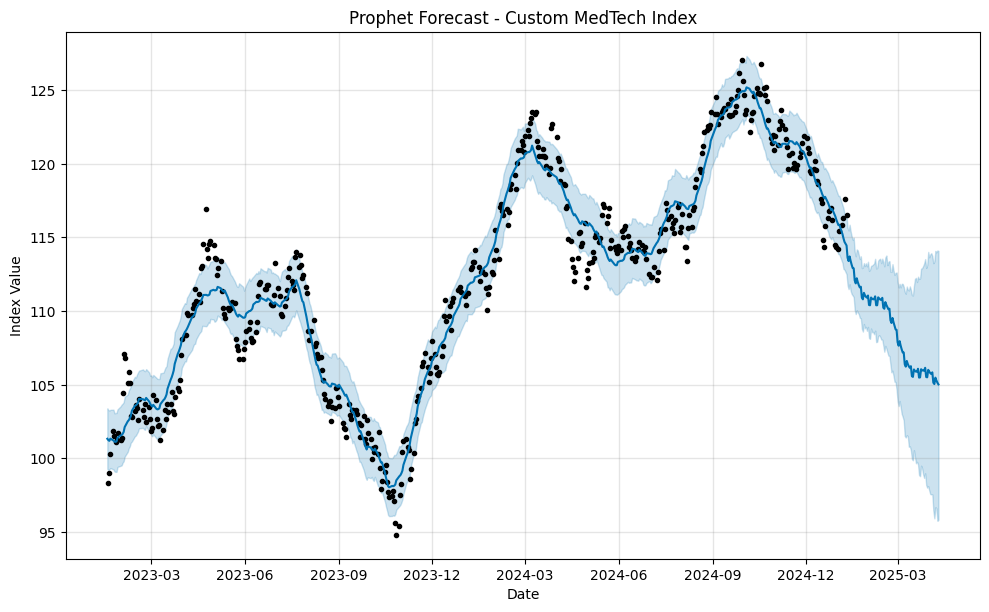

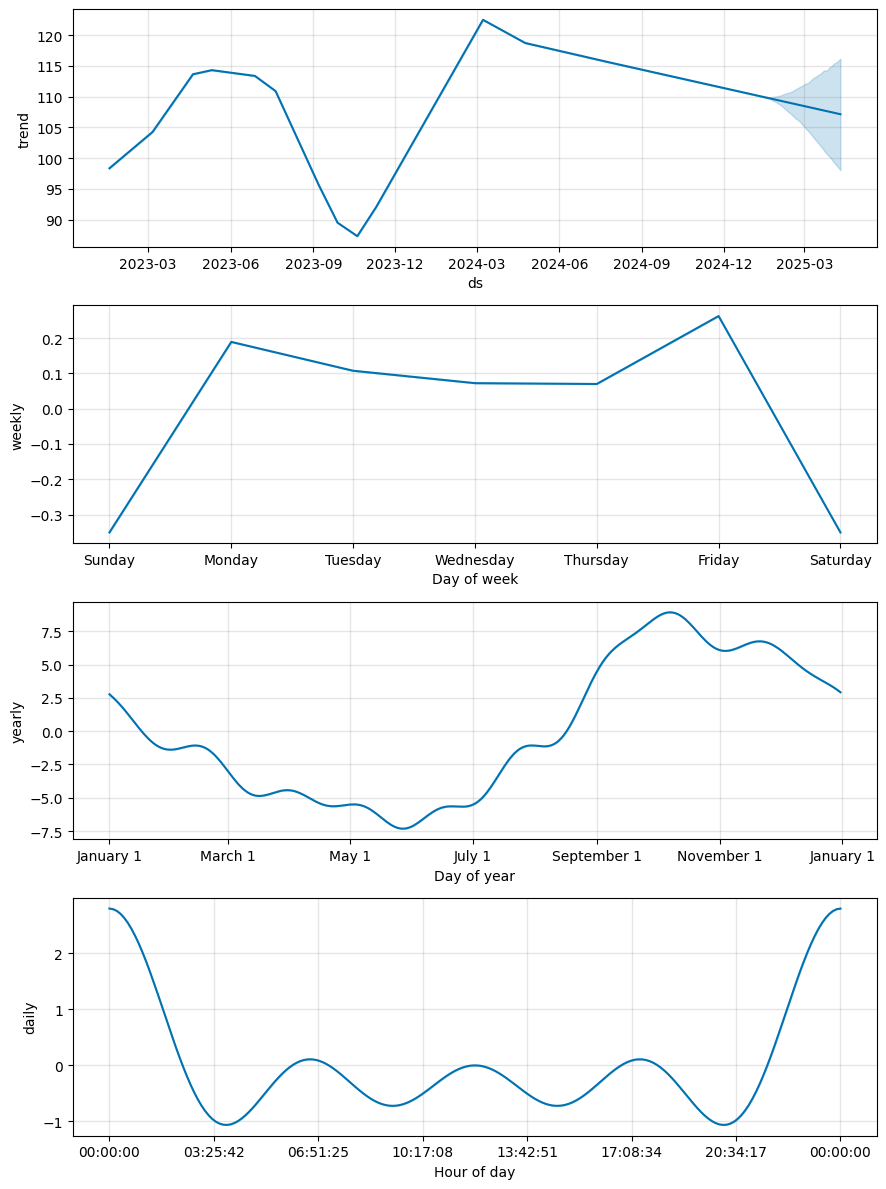

In [11]:
# 90 Day Forecasting
prophet_df = index_df.reset_index()
prophet_df.columns = ['ds', 'y']

model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=90)  # predict 90 days
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title("Prophet Forecast - Custom MedTech Index")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()